In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('/content/ipl_matches_data.csv', encoding='latin-1')
deliveries = pd.read_csv('/content/ball_by_ball_data.csv', encoding='latin-1')
players = pd.read_csv('/content/players-data-updated.csv', encoding='latin-1')
teams = pd.read_csv('/content/teams_data.csv', encoding='latin-1')

print('Matches:', matches.shape)
print('Deliveries:', deliveries.shape)
print('Players:', players.shape)
print('Teams:', teams.shape)

df = matches.head(5)
print(df)

Matches: (1169, 24)
Deliveries: (278205, 30)
Players: (772, 8)
Teams: (16, 4)
   match_id  season_id  balls_per_over       city  match_date  \
0    335982       2008               6  Bangalore  18-04-2008   
1   1082591       2017               6  Hyderabad  05-04-2017   
2   1082592       2017               6       Pune  06-04-2017   
3   1082593       2017               6     Rajkot  07-04-2017   
4   1082594       2017               6     Indore  08-04-2017   

              event_name  match_number gender match_type format  ...  \
0  Indian Premier League           1.0   male        T20    T20  ...   
1  Indian Premier League           1.0   male        T20    T20  ...   
2  Indian Premier League           2.0   male        T20    T20  ...   
3  Indian Premier League           3.0   male        T20    T20  ...   
4  Indian Premier League           4.0   male        T20    T20  ...   

                   toss_winner                        team1  \
0  Royal Challengers Bangalore  Roy

In [3]:
# Check dtypes — all files
print('\n=== MATCHES DTYPES ===')
print(matches.dtypes)

print('\n=== DELIVERIES DTYPES ===')
print(deliveries.dtypes)

print('\n=== PLAYERS DTYPES ===')
print(players.dtypes)

print('\n=== TEAMS DTYPES ===')
print(teams.dtypes)


=== MATCHES DTYPES ===
match_id             int64
season_id            int64
balls_per_over       int64
city                object
match_date          object
event_name          object
match_number       float64
gender              object
match_type          object
format              object
overs                int64
season              object
team_type           object
venue               object
toss_winner         object
team1               object
team2               object
toss_decision       object
match_winner        object
win_by_runs        float64
win_by_wickets     float64
player_of_match    float64
result              object
stage               object
dtype: object

=== DELIVERIES DTYPES ===
season_id             int64
match_id              int64
batter               object
bowler               object
non_striker          object
team_batting         object
team_bowling         object
over_number           int64
ball_number           int64
batter_runs           int64
extras 

In [4]:
# Fix match_date
matches['match_date'] = pd.to_datetime(matches['match_date'])

# Fix season
matches['season'] = matches['season'].astype(str).str[:4].astype(int)

# Fix match_number
matches['match_number'] = matches['match_number'].fillna(0).astype(int)

print(matches[['match_date', 'season', 'match_number']].dtypes)
print('Season unique values:', sorted(matches['season'].unique()))

match_date      datetime64[ns]
season                   int64
match_number             int64
dtype: object
Season unique values: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


/tmp/ipykernel_756/2904333393.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches['match_date'] = pd.to_datetime(matches['match_date'])


In [5]:
print('Dtype:', matches['player_of_match'].dtype)
print('Null count:', matches['player_of_match'].isnull().sum())
print('Sample values:', matches['player_of_match'].dropna().head(10).tolist())
print('Unique count:', matches['player_of_match'].nunique())

Dtype: float64
Null count: 8
Sample values: [46.0, 15.0, 36.0, 57.0, 71.0, 4.0, 22.0, 26.0, 70.0, 180.0]
Unique count: 308


In [6]:
# Player ID to Name mapping
player_id_map = dict(zip(players['player_id'].astype(str),
                         players['player_name']))

# Clean player_of_match — remove .0
matches['player_of_match'] = matches['player_of_match'].astype(str).str.replace('.0', '', regex=False)

# Map player ID to name
matches['player_of_match_name'] = matches['player_of_match'].map(player_id_map)

print(matches[['player_of_match', 'player_of_match_name']].head(10))
print()
print('Null after mapping:', matches['player_of_match_name'].isnull().sum())

  player_of_match player_of_match_name
0              46          BB McCullum
1              15         Yuvraj Singh
2              36            SPD Smith
3              57              CA Lynn
4              71           GJ Maxwell
5               4            KM Jadhav
6              22          Rashid Khan
7              26               N Rana
8              70             AR Patel
9             180            SV Samson

Null after mapping: 8


In [7]:
# Check nulls — all files
print('\n=== MATCHES NULL VALUES ===')
print(matches.isnull().sum())

print('\n=== DELIVERIES NULL VALUES ===')
print(deliveries.isnull().sum())

print('\n=== PLAYERS NULL VALUES ===')
print(players.isnull().sum())

print('\n=== TEAMS NULL VALUES ===')
print(teams.isnull().sum())


=== MATCHES NULL VALUES ===
match_id                   0
season_id                  0
balls_per_over             0
city                      51
match_date                 0
event_name                 0
match_number               0
gender                     0
match_type                 0
format                     0
overs                      0
season                     0
team_type                  0
venue                      0
toss_winner                1
team1                      0
team2                      0
toss_decision              1
match_winner               8
win_by_runs              638
win_by_wickets           554
player_of_match            0
result                     0
stage                   1165
player_of_match_name       8
dtype: int64

=== DELIVERIES NULL VALUES ===
season_id                 0
match_id                  0
batter                    0
bowler                    0
non_striker               0
team_batting              0
team_bowling              0
over_

In [8]:
# Check duplicates — all files
print('\n=== DUPLICATES ===')
print('Matches:', matches.duplicated().sum())
print('Deliveries:', deliveries.duplicated().sum())
print('Players:', players.duplicated().sum())
print('Teams:', teams.duplicated().sum())


=== DUPLICATES ===
Matches: 0
Deliveries: 0
Players: 0
Teams: 0


In [9]:
# Check unique team names
print('=== TEAM NAMES IN MATCHES ===')
print(sorted(matches['team1'].unique()))
print()
print('=== TEAMS FILE ===')
print(teams['team_name'].tolist())

=== TEAM NAMES IN MATCHES ===
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

=== TEAMS FILE ===
['Royal Challengers Bangalore', 'Sunrisers Hyderabad', 'Mumbai Indians', 'Rising Pune Supergiant', 'Gujarat Lions', 'Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans', 'Deccan Chargers', 'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants']


In [10]:
# Check Deccan Chargers
print(matches[matches['team1'].str.contains('Deccan', na=False)].shape)
print(matches[matches['team2'].str.contains('Deccan', na=False)].shape)

# Fix team names
team_name_mapping = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}

for col in ['team1', 'team2', 'toss_winner', 'match_winner']:
    matches[col] = matches[col].replace(team_name_mapping)

print('\nAfter fixing:')
print(sorted(matches['team1'].unique()))

(0, 25)
(0, 25)

After fixing:
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


                           Team  Wins
0                Mumbai Indians   153
1           Chennai Super Kings   142
2         Kolkata Knight Riders   135
3   Royal Challengers Bengaluru   133
4           Sunrisers Hyderabad   125
5                  Punjab Kings   123
6                Delhi Capitals   121
7              Rajasthan Royals   116
8                Gujarat Titans    37
9          Lucknow Super Giants    30
10      Rising Pune Supergiants    15
11                Gujarat Lions    13
12                Pune Warriors    12
13         Kochi Tuskers Kerala     6


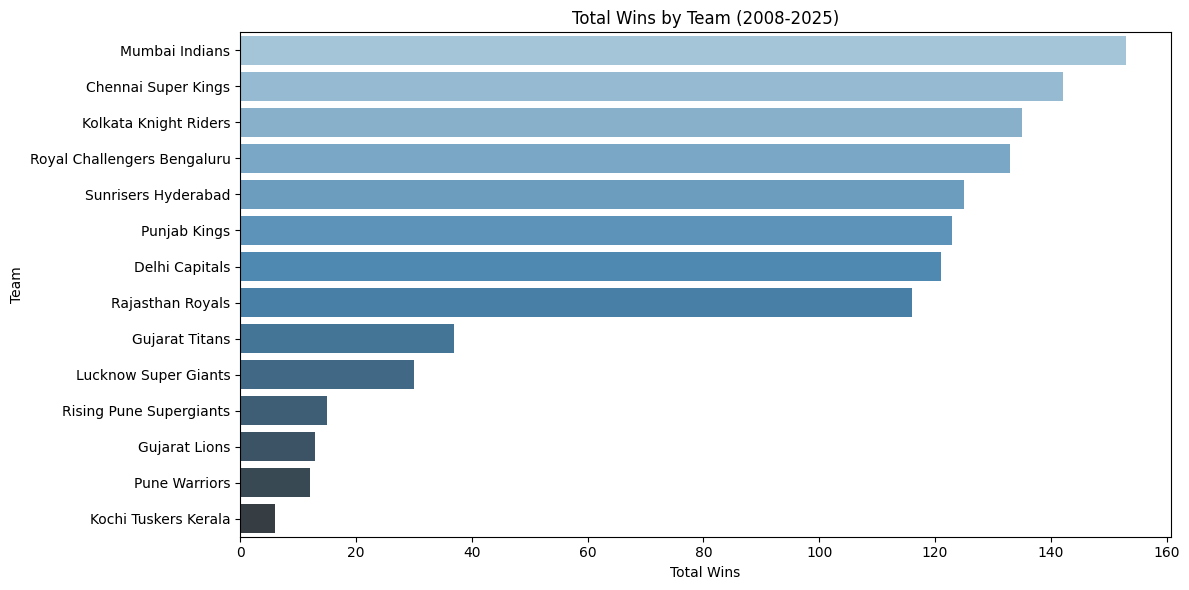

In [11]:
# Total wins per team
team_wins = matches['match_winner'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']
print(team_wins)

plt.figure(figsize=(12, 6))
sns.barplot(data=team_wins, x='Wins', y='Team',hue='Team', legend=False ,palette='Blues_d')
plt.title('Total Wins by Team (2008-2025)')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [12]:
# Check what stages are in our data
print(matches['stage'].value_counts())
print()
# Check result types
print(matches['result'].value_counts())

stage
Qualifier 1    1
Eliminator     1
Qualifier 2    1
Final          1
Name: count, dtype: int64

result
win          1146
tie            15
no result       8
Name: count, dtype: int64


In [13]:
# Check current nulls in stage
print("Stage nulls:", matches['stage'].isnull().sum())

matches['stage'] = matches['stage'].fillna('League')

print(matches['stage'].value_counts())

Stage nulls: 1165
stage
League         1165
Qualifier 1       1
Eliminator        1
Qualifier 2       1
Final             1
Name: count, dtype: int64


In [14]:
# Only wins
wins_only = matches[matches['result'] == 'win']
team_wins_clean = wins_only['match_winner'].value_counts().reset_index()
team_wins_clean.columns = ['Team', 'Wins']
print(team_wins_clean)

                           Team  Wins
0                Mumbai Indians   151
1           Chennai Super Kings   142
2         Kolkata Knight Riders   135
3   Royal Challengers Bengaluru   132
4           Sunrisers Hyderabad   122
5                  Punjab Kings   119
6                Delhi Capitals   118
7              Rajasthan Royals   114
8                Gujarat Titans    37
9          Lucknow Super Giants    30
10      Rising Pune Supergiants    15
11                Gujarat Lions    13
12                Pune Warriors    12
13         Kochi Tuskers Kerala     6


In [15]:
# SRH wins by season
srh_wins = wins_only[wins_only['match_winner'] == 'Sunrisers Hyderabad']
print(srh_wins.groupby('season')['match_id'].count())
print('Total SRH wins:', srh_wins.shape[0])

# Check when SRH started
print('\nSRH first match season:')
srh_matches = matches[(matches['team1'] == 'Sunrisers Hyderabad') |
                      (matches['team2'] == 'Sunrisers Hyderabad')]
print(srh_matches['season'].unique())

season
2008     2
2009     9
2010     8
2011     6
2012     4
2013     9
2014     6
2015     7
2016    11
2017     8
2018    10
2019     6
2020     8
2021     3
2022     6
2023     4
2024     9
2025     6
Name: match_id, dtype: int64
Total SRH wins: 122

SRH first match season:
[2017 2018 2019 2020 2021 2022 2023 2024 2025 2008 2009 2010 2011 2012
 2013 2014 2015 2016]


In [16]:
# Check 2008-2012 SRH matches
srh_early = matches[
    ((matches['team1'] == 'Sunrisers Hyderabad') |
     (matches['team2'] == 'Sunrisers Hyderabad')) &
    (matches['season'] < 2013)
]
print(srh_early[['season', 'team1', 'team2', 'match_winner']].head(10))

     season                  team1                        team2  \
530    2008  Kolkata Knight Riders          Sunrisers Hyderabad   
532    2008    Sunrisers Hyderabad               Delhi Capitals   
534    2008    Sunrisers Hyderabad             Rajasthan Royals   
538    2008         Mumbai Indians          Sunrisers Hyderabad   
543    2008    Sunrisers Hyderabad                 Punjab Kings   
546    2008    Sunrisers Hyderabad  Royal Challengers Bengaluru   
551    2008    Chennai Super Kings          Sunrisers Hyderabad   
555    2008       Rajasthan Royals          Sunrisers Hyderabad   
558    2008    Sunrisers Hyderabad        Kolkata Knight Riders   
564    2008         Delhi Capitals          Sunrisers Hyderabad   

                    match_winner  
530        Kolkata Knight Riders  
532               Delhi Capitals  
534             Rajasthan Royals  
538          Sunrisers Hyderabad  
543                 Punjab Kings  
546  Royal Challengers Bengaluru  
551          Sunr

In [17]:
# Fix — 2008-2012 SRH replace to Deccan Chargers
def fix_team_name(row, col):
    if row['season'] <= 2012 and row[col] == 'Sunrisers Hyderabad':
        return 'Deccan Chargers'
    return row[col]

for col in ['team1', 'team2', 'toss_winner', 'match_winner']:
    matches[col] = matches.apply(lambda row: fix_team_name(row, col), axis=1)

# Verify
print('SRH seasons after fix:')
srh = matches[(matches['team1'] == 'Sunrisers Hyderabad') |
              (matches['team2'] == 'Sunrisers Hyderabad')]
print(sorted(srh['season'].unique()))

print('\nDeccan Chargers seasons:')
dc = matches[(matches['team1'] == 'Deccan Chargers') |
             (matches['team2'] == 'Deccan Chargers')]
print(sorted(dc['season'].unique()))

SRH seasons after fix:
[np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Deccan Chargers seasons:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)]


In [18]:
# Recalculate wins after fix
wins_only = matches[matches['result'] == 'win']
team_wins_clean = wins_only['match_winner'].value_counts().reset_index()
team_wins_clean.columns = ['Team', 'Wins']
print(team_wins_clean)

                           Team  Wins
0                Mumbai Indians   151
1           Chennai Super Kings   142
2         Kolkata Knight Riders   135
3   Royal Challengers Bengaluru   132
4                  Punjab Kings   119
5                Delhi Capitals   118
6              Rajasthan Royals   114
7           Sunrisers Hyderabad    93
8                Gujarat Titans    37
9          Lucknow Super Giants    30
10              Deccan Chargers    29
11      Rising Pune Supergiants    15
12                Gujarat Lions    13
13                Pune Warriors    12
14         Kochi Tuskers Kerala     6


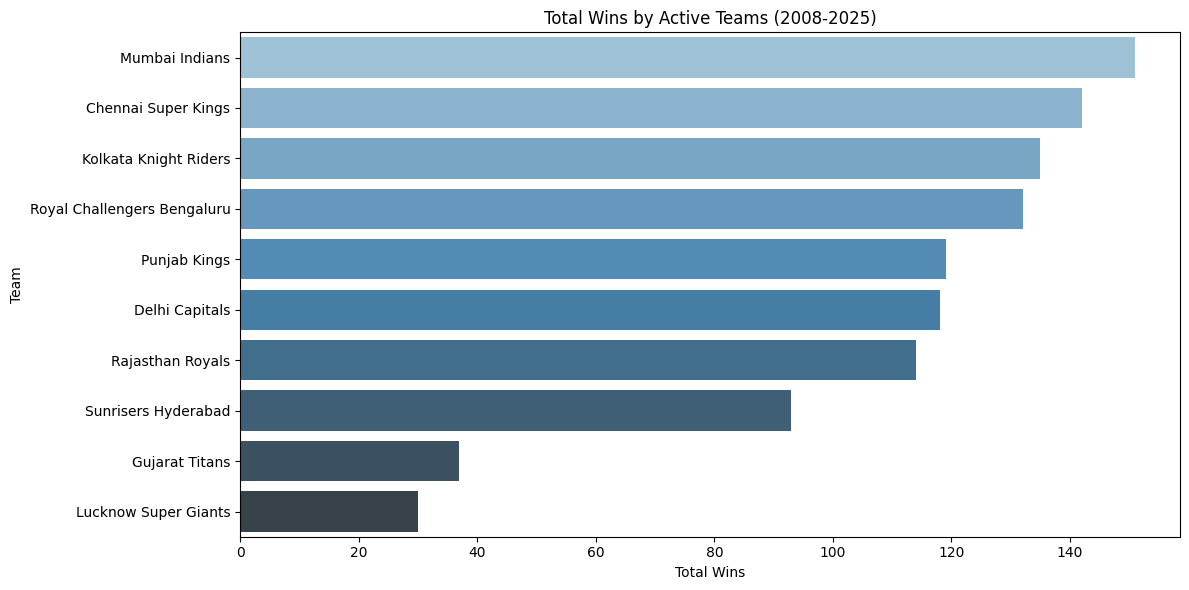

In [19]:
# Active teams only
active_teams = ['Mumbai Indians', 'Chennai Super Kings',
                'Royal Challengers Bengaluru', 'Kolkata Knight Riders',
                'Rajasthan Royals', 'Sunrisers Hyderabad',
                'Delhi Capitals', 'Punjab Kings',
                'Gujarat Titans', 'Lucknow Super Giants']

active_wins = team_wins_clean[team_wins_clean['Team'].isin(active_teams)]

plt.figure(figsize=(12, 6))
sns.barplot(data=active_wins.sort_values('Wins', ascending=False),
            x='Wins', y='Team',
            hue='Team', legend=False, palette='Blues_d')
plt.title('Total Wins by Active Teams (2008-2025)')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [20]:
# Wins per season for active teams
team_seasons = wins_only[wins_only['match_winner'].isin(active_teams)].groupby('match_winner')['season'].nunique().reset_index()
team_seasons.columns = ['Team', 'Seasons_Played']

active_performance = active_wins.merge(team_seasons, on='Team')
active_performance['Wins_Per_Season'] = (active_performance['Wins'] / active_performance['Seasons_Played']).round(2)
print(active_performance.sort_values('Wins_Per_Season', ascending=False))

                          Team  Wins  Seasons_Played  Wins_Per_Season
8               Gujarat Titans    37               4             9.25
1          Chennai Super Kings   142              16             8.88
0               Mumbai Indians   151              18             8.39
2        Kolkata Knight Riders   135              18             7.50
9         Lucknow Super Giants    30               4             7.50
3  Royal Challengers Bengaluru   132              18             7.33
7          Sunrisers Hyderabad    93              13             7.15
6             Rajasthan Royals   114              16             7.12
4                 Punjab Kings   119              18             6.61
5               Delhi Capitals   118              18             6.56


Toss Winner Won Match:
toss_won_match
True     598
False    571
Name: count, dtype: int64

Percentage:
toss_won_match
True     51.15
False    48.85
Name: proportion, dtype: float64


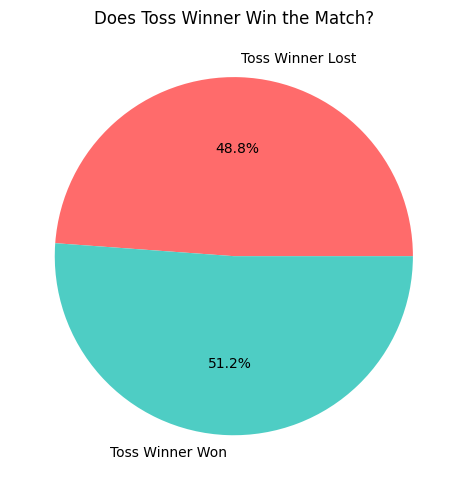

In [21]:
# Did toss winner win the match?
matches['toss_won_match'] = (matches['toss_winner'] == matches['match_winner'])

toss_impact = matches['toss_won_match'].value_counts()
toss_pct = matches['toss_won_match'].value_counts(normalize=True) * 100

print("Toss Winner Won Match:")
print(toss_impact)
print()
print("Percentage:")
print(toss_pct.round(2))

plt.figure(figsize=(6, 5))
labels = ['Toss Winner Lost', 'Toss Winner Won']
values = [toss_impact[False], toss_impact[True]]
colors = ['#FF6B6B', '#4ECDC4']
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title('Does Toss Winner Win the Match?')
plt.tight_layout()
plt.show()

toss_won_match  False  True 
toss_decision               
bat             54.21  45.79
field           45.94  54.06


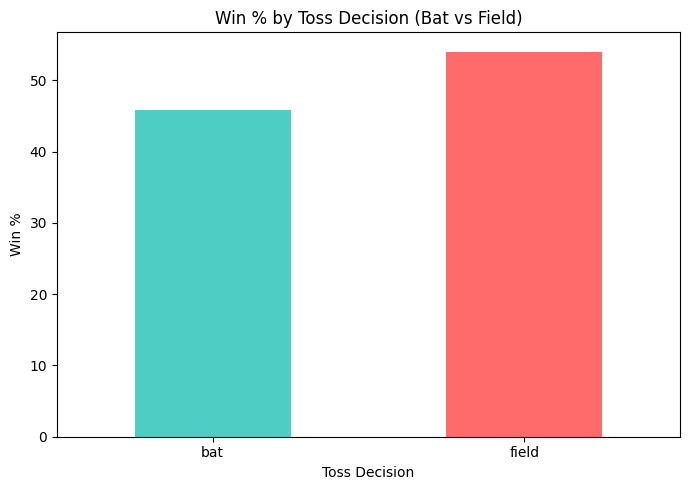

In [22]:
# Toss decision impact
toss_decision = matches.groupby('toss_decision')['toss_won_match'].value_counts(normalize=True).unstack() * 100
print(toss_decision.round(2))

plt.figure(figsize=(7, 5))
toss_decision[True].plot(kind='bar', color=['#4ECDC4', '#FF6B6B'])
plt.title('Win % by Toss Decision (Bat vs Field)')
plt.xlabel('Toss Decision')
plt.ylabel('Win %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

             Player  Total_Runs
658         V Kohli        8671
500       RG Sharma        7048
535        S Dhawan        6769
151       DA Warner        6567
569        SK Raina        5536
389        MS Dhoni        5439
297        KL Rahul        5235
31   AB de Villiers        5181
51        AM Rahane        5032
128        CH Gayle        4997


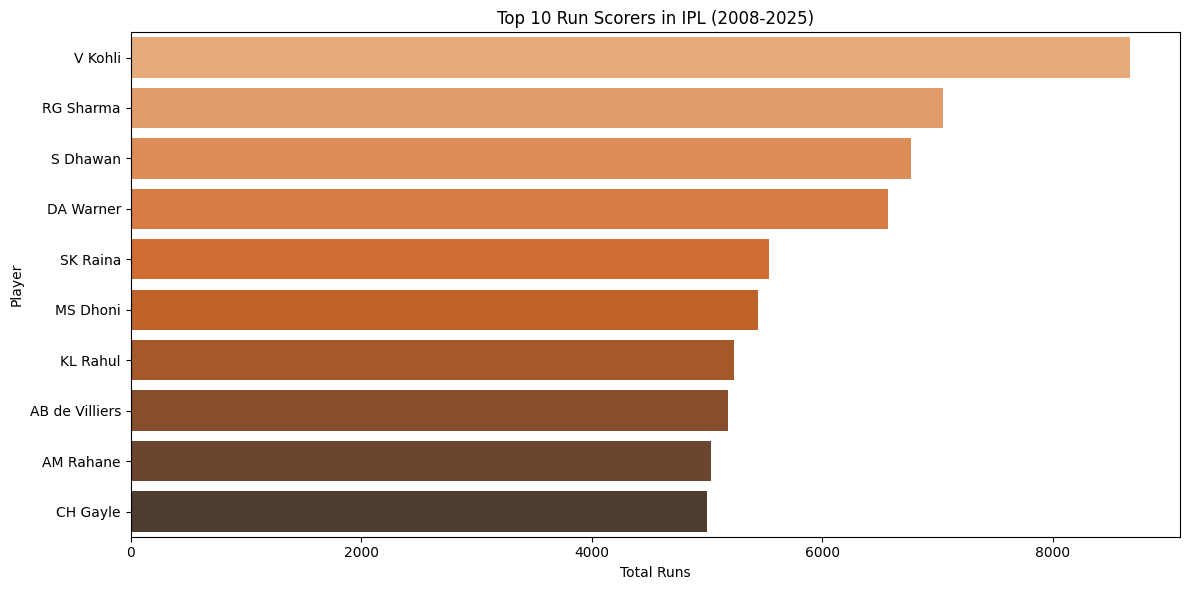

In [23]:
# Total runs per batsman
batsman_runs = deliveries.groupby('batter')['batter_runs'].sum().reset_index()
batsman_runs.columns = ['Player', 'Total_Runs']

# Top 10
top_10_batsmen = batsman_runs.sort_values('Total_Runs', ascending=False).head(10)
print(top_10_batsmen)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_batsmen, x='Total_Runs', y='Player',
            hue='Player', legend=False, palette='Oranges_d')
plt.title('Top 10 Run Scorers in IPL (2008-2025)')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

In [24]:
print(matches['stage'].value_counts())

stage
League         1165
Qualifier 1       1
Eliminator        1
Qualifier 2       1
Final             1
Name: count, dtype: int64


         Player  Wickets
463   YS Chahal      225
64      B Kumar      213
393   SP Narine      212
106    DJ Bravo      206
176   JJ Bumrah      203
318    R Ashwin      201
309   PP Chawla      198
386  SL Malinga      186
7      A Mishra      182
333   RA Jadeja      178


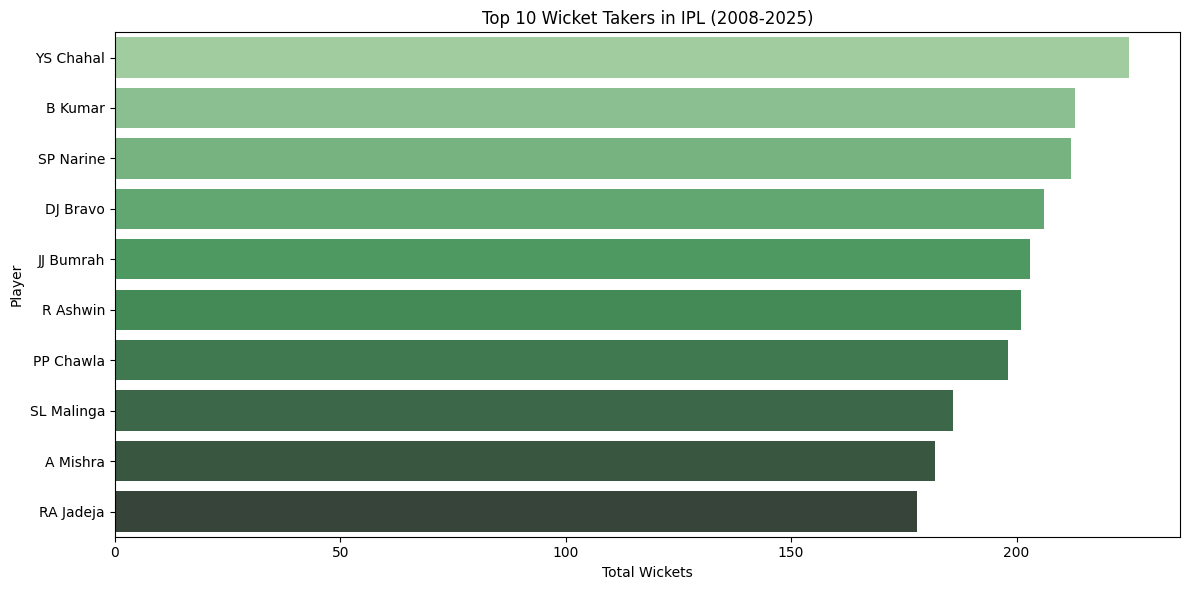

In [25]:
# Total wickets per bowler
# is_wicket = True means wicket happen — but wide and no ball means no wicket
bowler_wickets = deliveries[
    (deliveries['is_wicket'] == True) &
    (deliveries['is_wide_ball'] == False) &
    (deliveries['is_no_ball'] == False)
].groupby('bowler')['is_wicket'].count().reset_index()

bowler_wickets.columns = ['Player', 'Wickets']

# Top 10
top_10_bowlers = bowler_wickets.sort_values('Wickets', ascending=False).head(10)
print(top_10_bowlers)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_bowlers, x='Wickets', y='Player',
            hue='Player', legend=False, palette='Greens_d')
plt.title('Top 10 Wicket Takers in IPL (2008-2025)')
plt.xlabel('Total Wickets')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

In [26]:
# check Bowler type
top_bowler_types = deliveries[deliveries['bowler'].isin(top_10_bowlers['Player'])][['bowler', 'bowler_type']].drop_duplicates()
print(top_bowler_types)

           bowler             bowler_type
245     YS Chahal         Legbreak Googly
356       B Kumar        Right arm Medium
457     PP Chawla                Legbreak
624     JJ Bumrah          Right arm Fast
733     SP Narine      Right arm Offbreak
1230     A Mishra                Legbreak
1650   SL Malinga          Right arm Fast
3095    RA Jadeja  Slow Left arm Orthodox
14155    DJ Bravo        Right arm Medium
14333    R Ashwin      Right arm Offbreak


In [27]:
# Spinner or fast — automatically classify
def classify_bowler(bowler_type):
    if any(word in str(bowler_type).lower() for word in ['break', 'slow', 'spin', 'googly']):
        return 'Spinner'
    else:
        return 'Fast/Medium'

top_bowler_types['Category'] = top_bowler_types['bowler_type'].apply(classify_bowler)
print(top_bowler_types[['bowler', 'bowler_type', 'Category']])
print()
print(top_bowler_types['Category'].value_counts())

           bowler             bowler_type     Category
245     YS Chahal         Legbreak Googly      Spinner
356       B Kumar        Right arm Medium  Fast/Medium
457     PP Chawla                Legbreak      Spinner
624     JJ Bumrah          Right arm Fast  Fast/Medium
733     SP Narine      Right arm Offbreak      Spinner
1230     A Mishra                Legbreak      Spinner
1650   SL Malinga          Right arm Fast  Fast/Medium
3095    RA Jadeja  Slow Left arm Orthodox      Spinner
14155    DJ Bravo        Right arm Medium  Fast/Medium
14333    R Ashwin      Right arm Offbreak      Spinner

Category
Spinner        6
Fast/Medium    4
Name: count, dtype: int64


    season  avg_score_per_match
0     2008               160.97
1     2009               150.26
2     2010               164.78
3     2011               152.37
4     2012               157.54
5     2013               155.89
6     2014               163.07
7     2015               166.25
8     2016               162.60
9     2017               165.78
10    2018               172.47
11    2019               166.73
12    2020               169.50
13    2021               159.32
14    2022               171.12
15    2023               182.73
16    2024               189.59
17    2025               188.84


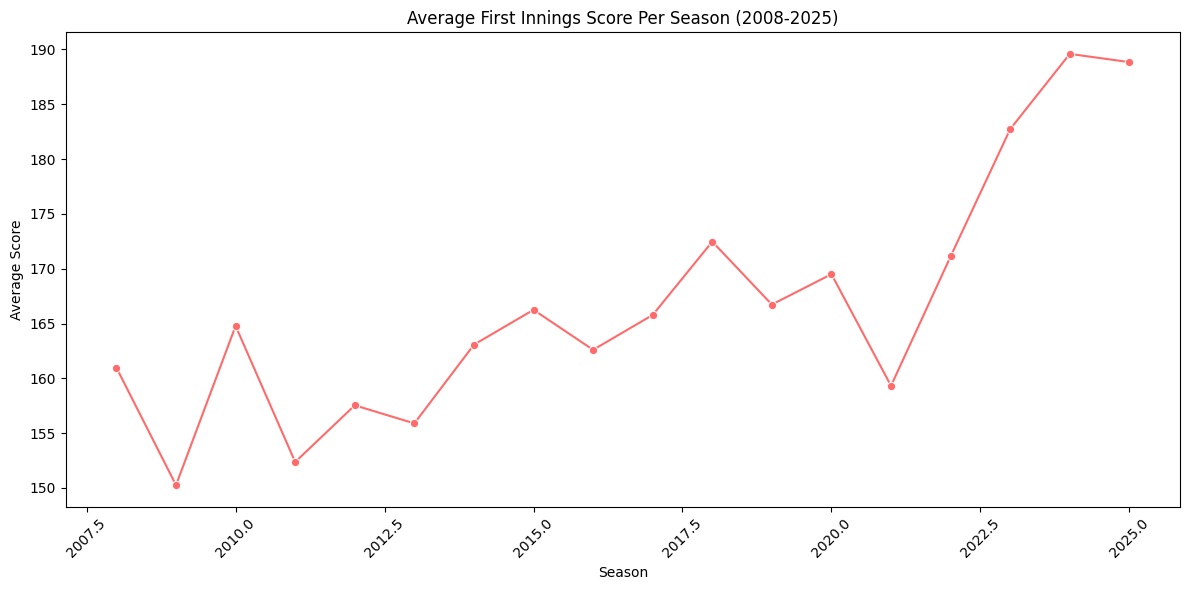

In [28]:
# First innings total runs per season
season_runs = deliveries[deliveries['innings'] == 1].groupby('season_id')['total_runs'].sum().reset_index()
season_runs.columns = ['season', 'total_runs']

# Total matches per season
season_matches = matches.groupby('season')['match_id'].count().reset_index()
season_matches.columns = ['season', 'total_matches']

# Merge and calculate average
season_avg = season_runs.merge(season_matches, on='season')
season_avg['avg_score_per_match'] = (season_avg['total_runs'] / season_avg['total_matches']).round(2)
print(season_avg[['season', 'avg_score_per_match']])

plt.figure(figsize=(12, 6))
sns.lineplot(data=season_avg, x='season', y='avg_score_per_match',
             marker='o', color='#FF6B6B')
plt.title('Average First Innings Score Per Season (2008-2025)')
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Check innings unique values
print(deliveries['innings'].unique())
print(deliveries['innings'].value_counts())

[1 2 3 4 5 6]
innings
1    144131
2    133903
3        83
4        76
5         8
6         4
Name: count, dtype: int64


Win by Runs: 531
Win by Wickets: 615
Win by Runs %: 46.34
Win by Wickets %: 53.66


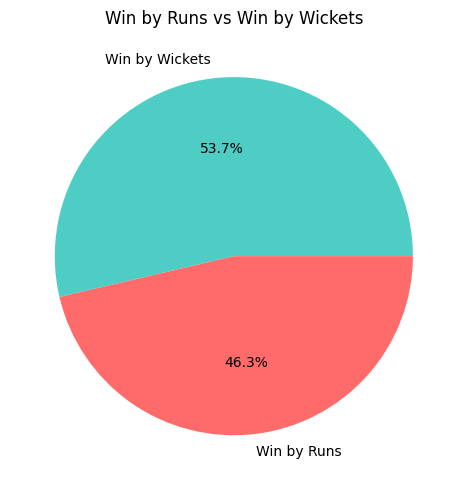

In [30]:
# Win type analysis
wins_by_runs = matches['win_by_runs'].notna().sum()
wins_by_wickets = matches['win_by_wickets'].notna().sum()

print(f"Win by Runs: {wins_by_runs}")
print(f"Win by Wickets: {wins_by_wickets}")
print(f"Win by Runs %: {round(wins_by_runs/1146*100, 2)}")
print(f"Win by Wickets %: {round(wins_by_wickets/1146*100, 2)}")

plt.figure(figsize=(6, 5))
labels = ['Win by Wickets', 'Win by Runs']
values = [wins_by_wickets, wins_by_runs]
colors = ['#4ECDC4', '#FF6B6B']
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title('Win by Runs vs Win by Wickets')
plt.tight_layout()
plt.show()

In [31]:
print(matches.columns.tolist())

['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result', 'stage', 'player_of_match_name', 'toss_won_match']


           Player  Awards
0  AB de Villiers      25
1        CH Gayle      22
2       RG Sharma      21
3         V Kohli      19
4        MS Dhoni      18
5       DA Warner      18
6       SP Narine      17
7       SR Watson      16
8       RA Jadeja      16
9      AD Russell      16


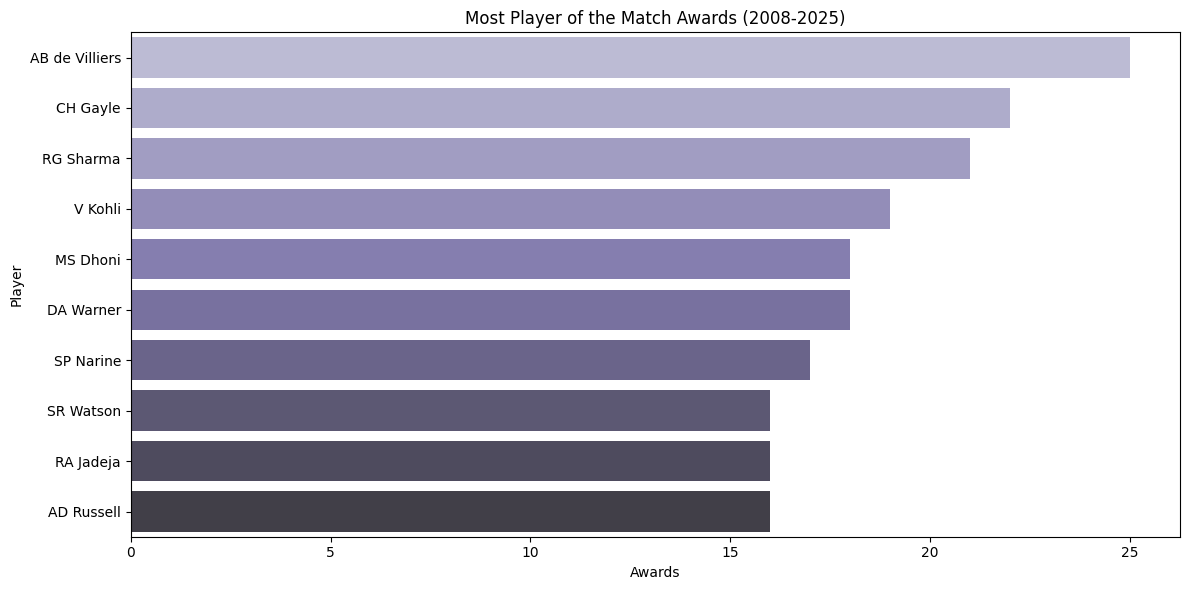

In [32]:
# Most player of the match awards
potm = matches['player_of_match_name'].value_counts().reset_index()
potm.columns = ['Player', 'Awards']

# Top 10
top_10_potm = potm.head(10)
print(top_10_potm)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_potm, x='Awards', y='Player',
            hue='Player', legend=False, palette='Purples_d')
plt.title('Most Player of the Match Awards (2008-2025)')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

                                                venue  Avg_Score  \
1                         Arun Jaitley Stadium, Delhi     200.35   
15                              Eden Gardens, Kolkata     196.78   
44  Rajiv Gandhi International Stadium, Uppal, Hyd...     189.37   
24                   M Chinnaswamy Stadium, Bengaluru     189.05   
48                     Sawai Mansingh Stadium, Jaipur     187.24   
33                   Narendra Modi Stadium, Ahmedabad     186.64   
5                                   Brabourne Stadium     180.40   
6                           Brabourne Stadium, Mumbai     177.41   
57                           Wankhede Stadium, Mumbai     176.83   
38       Punjab Cricket Association IS Bindra Stadium     175.60   

    Total_Matches  
1              23  
15             23  
44             19  
24             19  
48             17  
33             33  
5              10  
6              17  
57             52  
38             10  


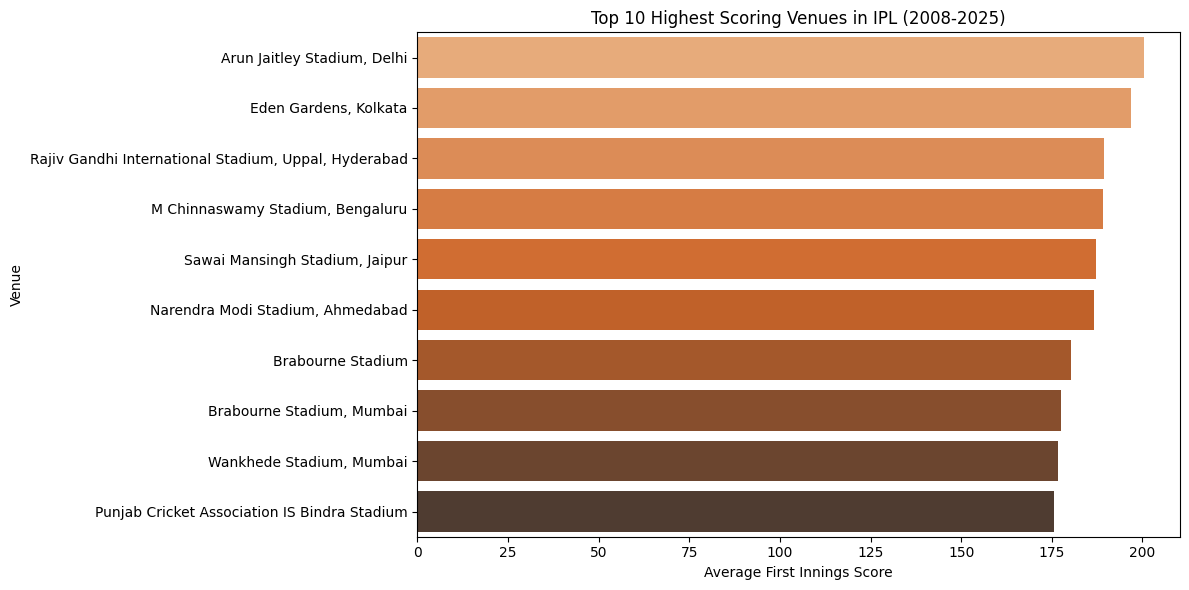

In [33]:
# Average score per venue — first innings only
venue_runs = deliveries[deliveries['innings'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
venue_runs.columns = ['match_id', 'first_innings_score']

# Merge with matches to get venue
venue_data = venue_runs.merge(matches[['match_id', 'venue']], on='match_id')

# Average score per venue — only venues with 10+ matches
venue_avg = venue_data.groupby('venue').agg(
    Avg_Score = ('first_innings_score', 'mean'),
    Total_Matches = ('match_id', 'count')
).reset_index()

# Filter — minimum 10 matches
venue_avg = venue_avg[venue_avg['Total_Matches'] >= 10]
venue_avg['Avg_Score'] = venue_avg['Avg_Score'].round(2)

# Top 10 highest scoring venues
top_venues = venue_avg.sort_values('Avg_Score', ascending=False).head(10)
print(top_venues)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_venues, x='Avg_Score', y='venue',
            hue='venue', legend=False, palette='Oranges_d')
plt.title('Top 10 Highest Scoring Venues in IPL (2008-2025)')
plt.xlabel('Average First Innings Score')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [34]:
matches['batting_first_won'] = (matches['toss_winner'] != matches['match_winner']) | (matches['toss_decision'] == 'bat')

# directly compare who batted first vs who won
def batted_first(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] == row['team2'] else row['team2']

matches['team_batting_first'] = matches.apply(batted_first, axis=1)
matches['first_innings_won'] = (matches['team_batting_first'] == matches['match_winner'])

# Only completed matches (result == 'win')
result_matches = matches[matches['result'] == 'win']

chase_defend = result_matches['first_innings_won'].value_counts()
chase_defend_pct = result_matches['first_innings_won'].value_counts(normalize=True) * 100

print("Batting First Won:", chase_defend.get(True, 0))
print("Batting Second (Chasing) Won:", chase_defend.get(False, 0))
print()
print("Percentage:")
print(chase_defend_pct.round(2))

Batting First Won: 525
Batting Second (Chasing) Won: 621

Percentage:
first_innings_won
False    54.19
True     45.81
Name: proportion, dtype: float64


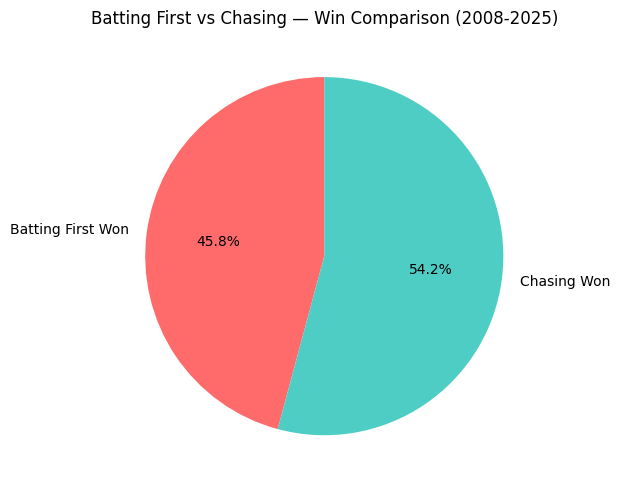

In [35]:
# Chasing vs Defending
plt.figure(figsize=(6, 5))
labels = ['Batting First Won', 'Chasing Won']
values = [chase_defend.get(True, 0), chase_defend.get(False, 0)]
colors = ['#FF6B6B', '#4ECDC4']

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Batting First vs Chasing — Win Comparison (2008-2025)')
plt.tight_layout()
plt.show()

In [36]:
print(deliveries.columns.tolist())
print(deliveries['over'].unique()[:10] if 'over' in deliveries.columns else 'No over column found')

['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']
No over column found


In [37]:
print(sorted(deliveries['over_number'].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


                     Team  Avg_Powerplay_Runs  Matches
2           Gujarat Lions               51.97       30
3          Gujarat Titans               50.23       60
6    Lucknow Super Giants               49.36       58
9            Punjab Kings               48.75      264
4    Kochi Tuskers Kerala               48.57       14
13    Sunrisers Hyderabad               48.57      270
1          Delhi Capitals               48.19      266
5   Kolkata Knight Riders               47.97      264
10       Rajasthan Royals               47.65      234
7          Mumbai Indians               47.51      277


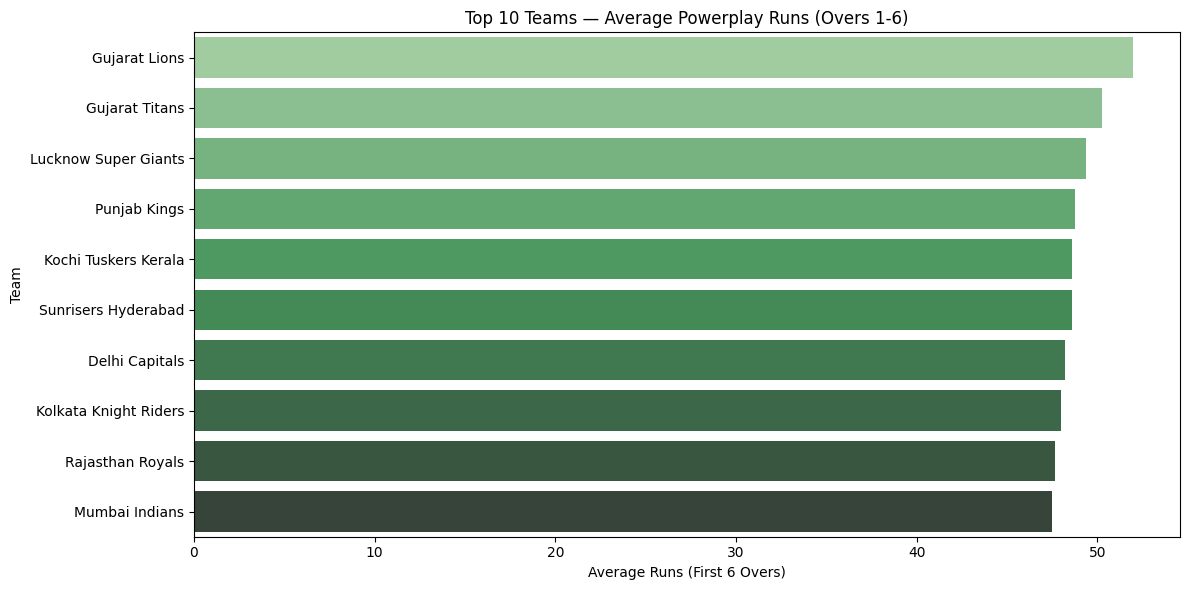

In [38]:
# Powerplay Analysis — Overs 0-5 (first 6 overs)
powerplay = deliveries[deliveries['over_number'] <= 5]

# Total powerplay runs per team + matches played (to get average)
pp_runs = powerplay.groupby(['match_id', 'team_batting'])['total_runs'].sum().reset_index()
pp_runs.columns = ['match_id', 'Team', 'Powerplay_Runs']

# Average powerplay runs per team
pp_avg = pp_runs.groupby('Team').agg(
    Avg_Powerplay_Runs=('Powerplay_Runs', 'mean'),
    Matches=('match_id', 'count')
).reset_index()

pp_avg['Avg_Powerplay_Runs'] = pp_avg['Avg_Powerplay_Runs'].round(2)

# Only teams with 10+ matches, top 10 by average
pp_avg_filtered = pp_avg[pp_avg['Matches'] >= 10].sort_values('Avg_Powerplay_Runs', ascending=False).head(10)
print(pp_avg_filtered)

plt.figure(figsize=(12, 6))
sns.barplot(data=pp_avg_filtered, x='Avg_Powerplay_Runs', y='Team',
            hue='Team', legend=False, palette='Greens_d')
plt.title('Top 10 Teams — Average Powerplay Runs (Overs 1-6)')
plt.xlabel('Average Runs (First 6 Overs)')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

            bowler  Runs_Conceded  Balls_Bowled  Legal_Balls  Economy
381  Sohail Tanvir            110            98           96     6.88
265     Noor Ahmad             98            83           80     7.35
97    DE Bollinger            268           216          210     7.66
210       M Ashwin             95            77           72     7.92
359      SP Narine           1019           767          751     8.14
352     SL Malinga           1252           965          917     8.19
181      KH Pandya            145           109          106     8.21
197  Kuldeep Yadav            257           194          186     8.29
212       M Kartik            122            88           88     8.32
220   M Theekshana            142           107          102     8.35


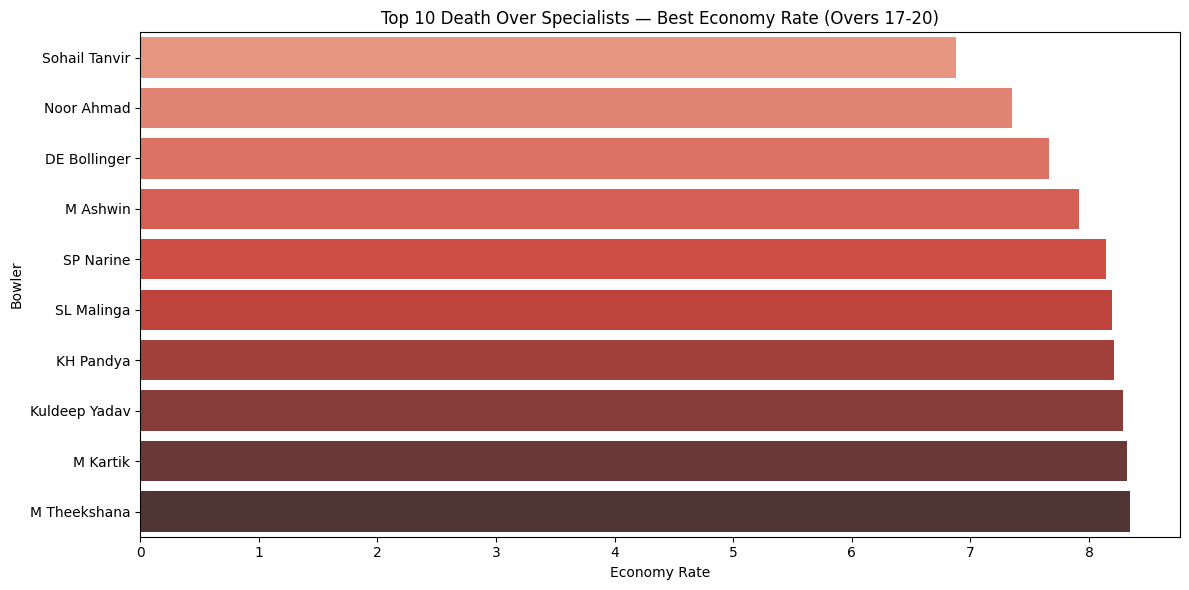

In [39]:
# Death Overs Bowling Analysis — Overs 16-19 (last 4 overs)
death_overs = deliveries[deliveries['over_number'] >= 16]

# Runs conceded per bowler in death overs (excluding byes/leg-byes — not bowler's fault)
death_runs = death_overs.groupby('bowler').agg(
    Runs_Conceded=('total_runs', 'sum'),
    Balls_Bowled=('bowler', 'count')
).reset_index()

# Remove wides/no-balls from ball count (they don't count as legal deliveries)
legal_balls = death_overs[(death_overs['is_wide_ball'] == False) & (death_overs['is_no_ball'] == False)]
legal_ball_count = legal_balls.groupby('bowler').size().reset_index(name='Legal_Balls')

death_runs = death_runs.merge(legal_ball_count, on='bowler')

# Economy rate = (runs / legal balls) * 6
death_runs['Economy'] = (death_runs['Runs_Conceded'] / death_runs['Legal_Balls'] * 6).round(2)

# Only bowlers with 60+ legal balls (10+ overs) in death overs — avoid small sample bias
death_bowlers = death_runs[death_runs['Legal_Balls'] >= 60].sort_values('Economy').head(10)
print(death_bowlers)

plt.figure(figsize=(12, 6))
sns.barplot(data=death_bowlers, x='Economy', y='bowler',
            hue='bowler', legend=False, palette='Reds_d')
plt.title('Top 10 Death Over Specialists — Best Economy Rate (Overs 17-20)')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

In [40]:
# Check how many players images there are.
print("Players with images:", players['player_image'].notna().sum())
print("Players without images:", players['player_image'].isna().sum())

# Check team logos
print(teams[['team_name', 'image_url']])

Players with images: 134
Players without images: 638
                      team_name  \
0   Royal Challengers Bangalore   
1           Sunrisers Hyderabad   
2                Mumbai Indians   
3        Rising Pune Supergiant   
4                 Gujarat Lions   
5         Kolkata Knight Riders   
6           Chennai Super Kings   
7              Rajasthan Royals   
8                Delhi Capitals   
9                  Punjab Kings   
10         Lucknow Super Giants   
11               Gujarat Titans   
12              Deccan Chargers   
13         Kochi Tuskers Kerala   
14                Pune Warriors   
15      Rising Pune Supergiants   

                                            image_url  
0   https://documents.iplt20.com/ipl/RCB/Logos/Log...  
1   https://documents.iplt20.com/ipl/SRH/Logos/Log...  
2   https://documents.iplt20.com/ipl/MI/Logos/Logo...  
3   https://ipl-stats-sports-mechanic.s3.ap-south-...  
4   https://ipl-stats-sports-mechanic.s3.ap-south-...  
5   https://doc

In [41]:
# Top 10 batsmen images
top_10_names = top_10_batsmen['Player'].tolist()
print("Top 10 Batsmen:")
print(players[players['player_name'].isin(top_10_names)][['player_name', 'player_image']])

print()

# Top 10 bowlers images
top_10_bowl_names = top_10_bowlers['Player'].tolist()
print("Top 10 Bowlers:")
print(players[players['player_name'].isin(top_10_bowl_names)][['player_name', 'player_image']])

Top 10 Batsmen:
        player_name                                       player_image
6         DA Warner  https://ipl-stats-sports-mechanic.s3.ap-south-...
21         SK Raina                                                NaN
58          V Kohli  https://ipl-stats-sports-mechanic.s3.ap-south-...
329       RG Sharma                                                NaN
502  AB de Villiers                                                NaN
530        MS Dhoni                                                NaN
605       AM Rahane  https://ipl-stats-sports-mechanic.s3.ap-south-...
636        CH Gayle  https://ipl-stats-sports-mechanic.s3.ap-south-...
696        S Dhawan  https://ipl-stats-sports-mechanic.s3.ap-south-...
731        KL Rahul  https://ipl-stats-sports-mechanic.s3.ap-south-...

Top 10 Bowlers:
    player_name                                       player_image
27    PP Chawla                                                NaN
61      B Kumar  https://ipl-stats-sports-mechanic.s

In [42]:
# Add missing URLs manually
player_image_updates = {
    'MS Dhoni': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/323900/323918.jpg',
    'RG Sharma': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/323900/323920.jpg',
    'SK Raina': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312207.jpg',
    'AB de Villiers': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312209.jpg',
}

for player, url in player_image_updates.items():
    players.loc[players['player_name'] == player, 'player_image'] = url

print(players[players['player_name'].isin(player_image_updates.keys())][['player_name', 'player_image']])

        player_name                                       player_image
21         SK Raina  https://img1.hscicdn.com/image/upload/f_auto,t...
329       RG Sharma  https://img1.hscicdn.com/image/upload/f_auto,t...
502  AB de Villiers  https://img1.hscicdn.com/image/upload/f_auto,t...
530        MS Dhoni  https://img1.hscicdn.com/image/upload/f_auto,t...


In [43]:
# Check remaining nulls in top 10 batsmen
print("Top 10 Batsmen Images Status:")
print(players[players['player_name'].isin(top_10_names)][['player_name', 'player_image']])

print()

# Check remaining nulls in top 10 bowlers
print("Top 10 Bowlers Images Status:")
print(players[players['player_name'].isin(top_10_bowl_names)][['player_name', 'player_image']])

Top 10 Batsmen Images Status:
        player_name                                       player_image
6         DA Warner  https://ipl-stats-sports-mechanic.s3.ap-south-...
21         SK Raina  https://img1.hscicdn.com/image/upload/f_auto,t...
58          V Kohli  https://ipl-stats-sports-mechanic.s3.ap-south-...
329       RG Sharma  https://img1.hscicdn.com/image/upload/f_auto,t...
502  AB de Villiers  https://img1.hscicdn.com/image/upload/f_auto,t...
530        MS Dhoni  https://img1.hscicdn.com/image/upload/f_auto,t...
605       AM Rahane  https://ipl-stats-sports-mechanic.s3.ap-south-...
636        CH Gayle  https://ipl-stats-sports-mechanic.s3.ap-south-...
696        S Dhawan  https://ipl-stats-sports-mechanic.s3.ap-south-...
731        KL Rahul  https://ipl-stats-sports-mechanic.s3.ap-south-...

Top 10 Bowlers Images Status:
    player_name                                       player_image
27    PP Chawla                                                NaN
61      B Kumar  https:/

In [44]:
bowler_image_updates = {
    'PP Chawla': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312254.jpg',
    'SP Narine': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312244.jpg',
    'A Mishra': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312225.jpg',
    'RA Jadeja': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/323900/323919.jpg',
    'JJ Bumrah': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/323900/323917.jpg',
}

for player, url in bowler_image_updates.items():
    players.loc[players['player_name'] == player, 'player_image'] = url

print(players[players['player_name'].isin(top_10_bowl_names)][['player_name', 'player_image']])

    player_name                                       player_image
27    PP Chawla  https://img1.hscicdn.com/image/upload/f_auto,t...
61      B Kumar  https://ipl-stats-sports-mechanic.s3.ap-south-...
63    SP Narine  https://img1.hscicdn.com/image/upload/f_auto,t...
66     A Mishra  https://img1.hscicdn.com/image/upload/f_auto,t...
72     DJ Bravo  https://ipl-stats-sports-mechanic.s3.ap-south-...
548    R Ashwin  https://www.espncricinfo.com/cricketers/ravich...
572   RA Jadeja  https://img1.hscicdn.com/image/upload/f_auto,t...
583   JJ Bumrah  https://img1.hscicdn.com/image/upload/f_auto,t...
617   YS Chahal  https://ipl-stats-sports-mechanic.s3.ap-south-...
739  SL Malinga  https://ipl-stats-sports-mechanic.s3.ap-south-...


In [45]:
# Top 10 POTM players
top_10_potm_names = top_10_potm['Player'].tolist()
print("Top 10 POTM Images Status:")
print(players[players['player_name'].isin(top_10_potm_names)][['player_name', 'player_image']])

Top 10 POTM Images Status:
        player_name                                       player_image
6         DA Warner  https://ipl-stats-sports-mechanic.s3.ap-south-...
58          V Kohli  https://ipl-stats-sports-mechanic.s3.ap-south-...
63        SP Narine  https://img1.hscicdn.com/image/upload/f_auto,t...
69        SR Watson                                                NaN
329       RG Sharma  https://img1.hscicdn.com/image/upload/f_auto,t...
366      AD Russell  https://ipl-stats-sports-mechanic.s3.ap-south-...
502  AB de Villiers  https://img1.hscicdn.com/image/upload/f_auto,t...
530        MS Dhoni  https://img1.hscicdn.com/image/upload/f_auto,t...
572       RA Jadeja  https://img1.hscicdn.com/image/upload/f_auto,t...
636        CH Gayle  https://ipl-stats-sports-mechanic.s3.ap-south-...


In [46]:
potm_image_updates = {
    'SR Watson': 'https://img1.hscicdn.com/image/upload/f_auto,t_ds_square_w_160,q_50/lsci/db/PICTURES/CMS/312200/312258.jpg',
}

for player, url in potm_image_updates.items():
    players.loc[players['player_name'] == player, 'player_image'] = url

print(players[players['player_name'] == 'SR Watson'][['player_name', 'player_image']])

   player_name                                       player_image
69   SR Watson  https://img1.hscicdn.com/image/upload/f_auto,t...


In [47]:
name_fixes = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

# Fix in teams table
teams['team_name'] = teams['team_name'].replace(name_fixes)

for col in ['team1', 'team2', 'toss_winner', 'match_winner']:
    matches[col] = matches[col].replace(name_fixes)

# Fix in deliveries table (team_batting, team_bowling)
for col in ['team_batting', 'team_bowling']:
    deliveries[col] = deliveries[col].replace(name_fixes)

# Remove duplicate team_id row
teams = teams.drop_duplicates(subset='team_name', keep='last').reset_index(drop=True)

print("Unique teams now:", teams['team_name'].nunique())
print(teams[teams['team_name'].str.contains('Pune', case=False, na=False)])

Unique teams now: 15
    team_id                team_name team_name_short  \
13     1419            Pune Warriors             PWI   
14     3604  Rising Pune Supergiants             RPS   

                                            image_url  
13  https://ipl-stats-sports-mechanic.s3.ap-south-...  
14  https://ipl-stats-sports-mechanic.s3.ap-south-...  


In [48]:
def classify_bowler(bowl_type):
    if pd.isna(bowl_type):
        return 'Unknown'
    bowl_type = bowl_type.lower()
    if 'spin' in bowl_type or 'break' in bowl_type or 'orthodox' in bowl_type or 'chinaman' in bowl_type:
        return 'Spinner'
    else:
        return 'Pace/Fast'

players['bowler_category'] = players['bowl_style'].apply(classify_bowler)

In [49]:
matches['stage'].unique()

array(['League', 'Qualifier 1', 'Eliminator', 'Qualifier 2', 'Final'],
      dtype=object)